### Comparison to Figure 3 of Bakker (2019)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import timflow.transient as tft

In [22]:
k = 20  # m/d
H = 10  # m
Ss = 1e-4  # 1/m
Sp = 0.1  # -
c = 500  # d
tsandhstar = [(0, 1)]

In [23]:
def model(zland, leffaq=0, cland=1e12, Sland=Ss, land_top="conf", land_phreatic=False):
    ml = tft.ModelXsection(naq=1, tmin=1e-4, tmax=1e2)

    tft.XsectionMaq(
        model=ml,
        x1=-np.inf,  # river extends to infinitiy
        x2=0,
        z=[1, 0, -H],
        kaq=k,
        Saq=Ss,
        c=c,
        leffaq=leffaq,
        topboundary="semi",
        tsandhstar=tsandhstar,
        name="river",
    )

    tft.XsectionMaq(
        model=ml,
        x1=0,
        x2=np.inf,  # hinterland extends to infinity
        kaq=k,
        z=zland,
        Saq=Sland,
        c=cland,
        topboundary=land_top,
        phreatictop=land_phreatic,
        name="land",
    )

    ml.solve()
    return ml

In [31]:
ml_leff = []
ml_noleff = []
# land is confined
ml_leff.append(model([0, -H], leffaq=1, Sland=Ss, land_top="conf", land_phreatic=False))
ml_noleff.append(model([0, -H], leffaq=0, Sland=Ss, land_top="conf", land_phreatic=False))
# land is semi-confined
ml_leff.append(
    model([1, 0, -H], leffaq=1, cland=c, Sland=Ss, land_top="semi", land_phreatic=False)
)
ml_noleff.append(
    model([1, 0, -H], leffaq=0, cland=c, Sland=Ss, land_top="semi", land_phreatic=False)
)
# land is phreatic
ml_leff.append(model([0, -H], leffaq=1, Sland=Sp, land_top="conf", land_phreatic=True))
ml_noleff.append(model([0, -H], leffaq=0, Sland=Sp, land_top="conf", land_phreatic=True))

self.neq  2
solution complete
self.neq  2
solution complete
self.neq  2
solution complete
self.neq  2
solution complete
self.neq  2
solution complete
self.neq  2
solution complete


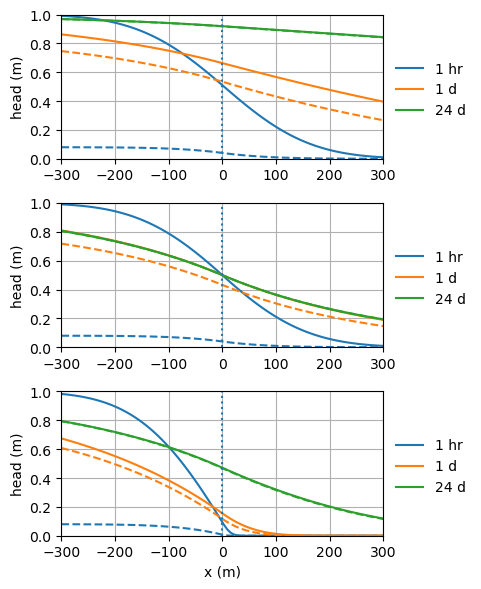

In [35]:
x = np.linspace(-300, 300, 100)
t = [1 / 24, 1, 24]
plt.figure(figsize=(5, 6))
for i in range(len(ml_leff)):
    ha = ml_leff[i].headalongline(x, 0, t).squeeze()
    hb = ml_noleff[i].headalongline(x, 0, t).squeeze()
    plt.subplot(3, 1, i + 1)
    legendtext = ["1 hr", "1 d", "24 d"]
    for i in range(len(t)):
        plt.plot(x, ha[i], color="C" + str(i), label=legendtext[i])
        plt.plot(x, hb[i], "--", color="C" + str(i))
    plt.axvline(0, linestyle=":")
    plt.xlim(-300, 300)
    plt.ylim(0, 1)
    plt.legend(loc="lower left", bbox_to_anchor=(1, 0.2), frameon=False)
    plt.ylabel("head (m)")
    plt.grid()
plt.xlabel("x (m)")
plt.tight_layout()

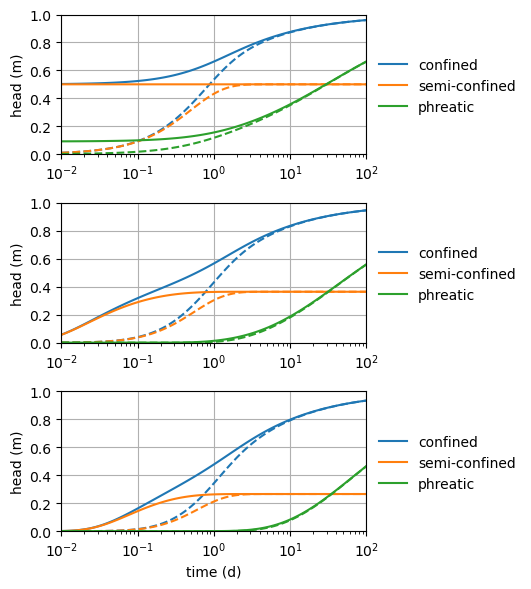

In [58]:
t = np.logspace(-2, 2, 100)
x = [0, 100, 200]
plt.figure(figsize=(5.5, 6))
for i in range(len(x)):
    plt.subplot(3, 1, i + 1)
    legendtext = ["confined", "semi-confined", "phreatic"]
    for im in range(len(ml_leff)):
        ha = ml_leff[im].head(x[i], 0, t).squeeze()
        hb = ml_noleff[im].head(x[i], 0, t).squeeze()
        plt.semilogx(t, ha, color="C" + str(im), label=legendtext[im])
        plt.semilogx(t, hb, "--", color="C" + str(im))
    plt.axvline(0, linestyle=":")
    plt.xlim(0.01, 100)
    plt.ylim(0, 1)
    plt.legend(loc="lower left", bbox_to_anchor=(1, 0.2), frameon=False)
    plt.ylabel("head (m)")
    plt.grid()
plt.xlabel("time (d)")
plt.tight_layout()

### Reference
Bakker, M., 2016. The effect of loading efficiency on the groundwater response to water level changes in shallow lakes and streams. Water Resources Research, 52(3), pp.1705-1715, [https://doi.org/10.1002/2015WR017977](https://doi.org/10.1002/2015WR017977).